In [2034]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Understand the Dataset

In [2035]:
df=pd.read_csv(r"C:\Users\SANTHOSH\Downloads\Datasets\messy_ecommerce_sales_data.csv")
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


# Check dataset size

In [2036]:
df.shape

(103, 11)

In [2037]:
df.size

1133

# Inspect column names and data types

In [2038]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product',
       ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

In [2039]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2040]:
numeric_columns= df.select_dtypes(include=['int','float'])
numeric_columns.columns

Index(['ID', 'Total'], dtype='object')

In [2041]:
object_columns= df.select_dtypes(include='object')
object_columns.columns

Index([' Customer_Name', 'Order_ID', 'Order_Date', 'Product', ' Category',
       'Quantity', 'Price', 'Payment_Method', 'Status'],
      dtype='object')

# Check for missing values

In [2042]:
df.isna().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [2043]:
df.isna().sum().sum()

32

# Check for duplicate records

In [2044]:
df.duplicated().sum()

1

In [2045]:
df.drop_duplicates(inplace=True)
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [2046]:
df.duplicated().sum()

0

# Generate statistical summary

In [2047]:
df.describe()

,ID,Total
count,102.000000,88.000000
mean,149.676471,1230.927614
std,28.843779,2620.332451
min,100.000000,-20000.000000
25%,125.250000,574.725000
50%,149.500000,1127.180000
75%,174.750000,2179.652500
max,199.000000,4722.700000


# Data Type Conversion

In [2048]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2049]:
df['Order_Date']=pd.to_datetime(df['Order_Date'],format='mixed',errors='coerce').dt.date

In [2050]:
df['Order_Date'].tail(20)

82     2025-08-03
83     2025-03-10
84     2025-02-15
85     2025-08-14
86     2025-10-06
87     2024-11-19
88     2024-11-19
89     2025-08-14
90     2025-06-29
91     2025-07-18
92            NaT
93     2025-06-06
94     2025-02-10
95     2025-06-19
96     2024-12-23
97     2025-06-23
98     2025-07-27
99     2025-01-22
100    2025-02-24
101    2025-10-30
Name: Order_Date, dtype: object

In [2051]:
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])
df['Order_Date']

0      2024-11-22
1      2025-07-05
2      2024-12-23
3      2025-03-19
4      2025-10-20
          ...    
97     2025-06-23
98     2025-07-27
99     2025-01-22
100    2025-02-24
101    2025-10-30
Name: Order_Date, Length: 102, dtype: object

In [2052]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2053]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [2054]:
df['Quantity'] 

0      3.0
1      2.0
2      1.0
3      5.0
4      1.0
      ... 
97     1.0
98     2.0
99     5.0
100    1.0
101    5.0
Name: Quantity, Length: 102, dtype: float64

In [2055]:
df['Quantity'].unique()

array([ 3.,  2.,  1.,  5., nan,  4., -2., -5.])

In [2056]:
df['Quantity'].tail(102)

0      3.0
1      2.0
2      1.0
3      5.0
4      1.0
      ... 
97     1.0
98     2.0
99     5.0
100    1.0
101    5.0
Name: Quantity, Length: 102, dtype: float64

In [2057]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity          float64
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2058]:
df['Quantity'].isna().sum()

6

In [2059]:
df['Quantity']=df['Quantity'].abs()

In [2060]:
df['Quantity']

0      3.0
1      2.0
2      1.0
3      5.0
4      1.0
      ... 
97     1.0
98     2.0
99     5.0
100    1.0
101    5.0
Name: Quantity, Length: 102, dtype: float64

In [2061]:
df['Quantity'].isna().sum()

6

In [2062]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)

In [2063]:
df['Quantity']

0      3
1      2
2      1
3      5
4      1
      ..
97     1
98     2
99     5
100    1
101    5
Name: Quantity, Length: 102, dtype: int32

In [2064]:
df['Quantity'].isna().sum()

0

In [2065]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int32
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2066]:
df['Price']

0          38
1         abd
2      389.05
3      233.92
4      552.51
        ...  
97     160.16
98     497.01
99     372.28
100    111.36
101    645.26
Name: Price, Length: 102, dtype: object

In [2067]:
df['Price'].isna().sum()

5

In [2068]:
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

In [2069]:
df['Price']

0       38.00
1         NaN
2      389.05
3      233.92
4      552.51
        ...  
97     160.16
98     497.01
99     372.28
100    111.36
101    645.26
Name: Price, Length: 102, dtype: float64

In [2070]:
df['Price'].isna().sum()

9

In [2071]:
df['Price'].fillna(df['Price'].mean(),inplace=True)

In [2072]:
df['Price']

0       38.000000
1      611.998172
2      389.050000
3      233.920000
4      552.510000
          ...    
97     160.160000
98     497.010000
99     372.280000
100    111.360000
101    645.260000
Name: Price, Length: 102, dtype: float64

In [2073]:
df['Price']=df['Price'].astype(int)

In [2074]:
df['Price']

0       38
1      611
2      389
3      233
4      552
      ... 
97     160
98     497
99     372
100    111
101    645
Name: Price, Length: 102, dtype: int32

In [2075]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int32
Price               int32
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2076]:
df['Price'].isna().sum()

0

In [2077]:
df.isna().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           0
Price              0
Payment_Method     0
Status             0
Total             14
dtype: int64

In [2078]:
df['Total']=pd.to_numeric(df['Total'])

In [2079]:
df['Total']

0       114.000
1           NaN
2       389.050
3      1169.600
4       552.510
         ...   
97      160.160
98      994.020
99     1861.400
100      77.952
101    3226.300
Name: Total, Length: 102, dtype: float64

In [2080]:
df['Total'].fillna(df['Quantity']*df['Price'],inplace=True)

In [2081]:
df['Total'].isna().sum()

0

In [2082]:
df['Total'].isin(df['Total']== -20000).sum()

0

In [2083]:
df['Total'].astype(int)

0       114
1      1222
2       389
3      1169
4       552
       ... 
97      160
98      994
99     1861
100      77
101    3226
Name: Total, Length: 102, dtype: int32

In [2084]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int32
Price               int32
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2085]:
df.isna().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         8
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [2086]:
df[' Category'] = df[' Category'].str.strip().str.lower()

In [2087]:
df[' Category']

0             home
1      electronics
2           sports
3            books
4            books
          ...     
97            home
98             NaN
99            home
100    electronics
101       clothing
Name:  Category, Length: 102, dtype: object

In [2088]:
df[' Category'].isna().sum()

8

In [2089]:
df[' Category'].head()

0           home
1    electronics
2         sports
3          books
4          books
Name:  Category, dtype: object

In [2090]:
df[' Category'].replace({'nan':np.nan},inplace=True)

In [2091]:
df[' Category'].tail()

97            home
98             NaN
99            home
100    electronics
101       clothing
Name:  Category, dtype: object

In [2092]:
df[' Category'].fillna(df[' Category'].mode()[0],inplace=True)
df.loc[84,' Category']

'books'

In [2093]:
df.isna().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [2094]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int32
Price               int32
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2095]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,electronics,2,611,PayPal,Processing,1222.00
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,sports,1,389,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,books,5,233,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,books,1,552,Cash on Delivery,Processing,552.51


In [2096]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product',
       ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

In [2097]:
numeric_columns= df.select_dtypes(include=['int','float'])
numeric_columns.columns

Index(['ID', 'Quantity', 'Price', 'Total'], dtype='object')

In [2098]:
object_columns= df.select_dtypes(include='object')
object_columns.columns

Index([' Customer_Name', 'Order_ID', 'Order_Date', 'Product', ' Category',
       'Payment_Method', 'Status'],
      dtype='object')

In [2099]:
date_columns=df.select_dtypes(include='datetime')
date_columns.columns

Index([], dtype='object')

In [2100]:
df.describe()

,ID,Quantity,Price,Total
count,102.000000,102.000000,102.000000,102.000000
mean,149.676471,3.068627,611.500000,1344.447353
std,28.843779,1.477621,973.144192,2467.941057
min,100.000000,1.000000,-100.000000,-20000.000000
25%,125.250000,2.000000,292.500000,645.263000
50%,149.500000,3.000000,575.500000,1230.550000
75%,174.750000,4.750000,702.750000,2377.430000
max,199.000000,5.000000,10000.000000,4722.700000


# Uni-Variate Analysis

In [2101]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product',
       ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

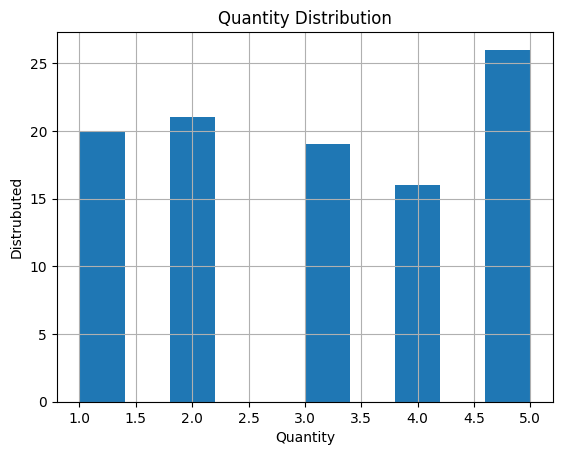

In [2102]:
df['Quantity'].hist()
plt.title("Quantity Distribution")
plt.xlabel('Quantity')
plt.ylabel('Distrubuted')
plt.show()


# Detect Numerical_Cols Outliers

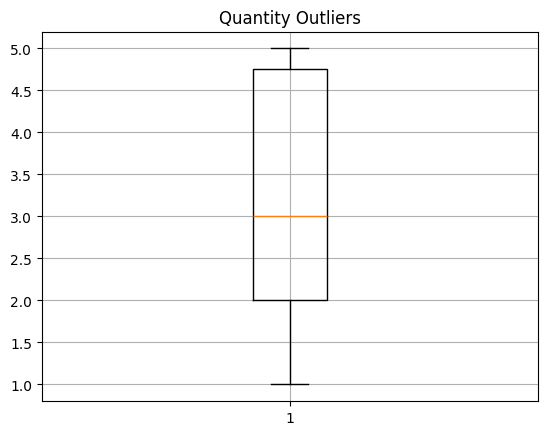

In [2103]:
plt.boxplot(df['Quantity'])
plt.title('Quantity Outliers')
plt.grid()
plt.show()

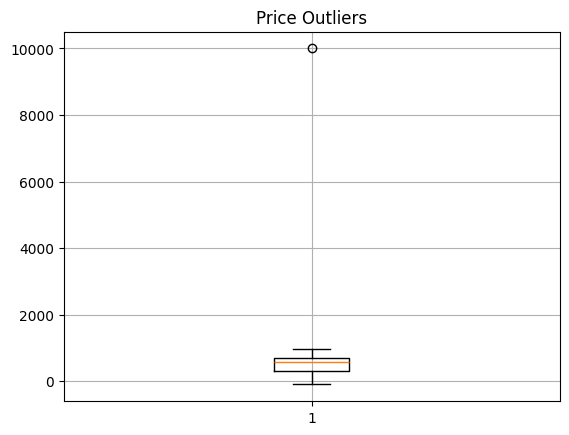

In [2104]:
plt.boxplot(df['Price'])
plt.title('Price Outliers')
plt.grid()
plt.show()

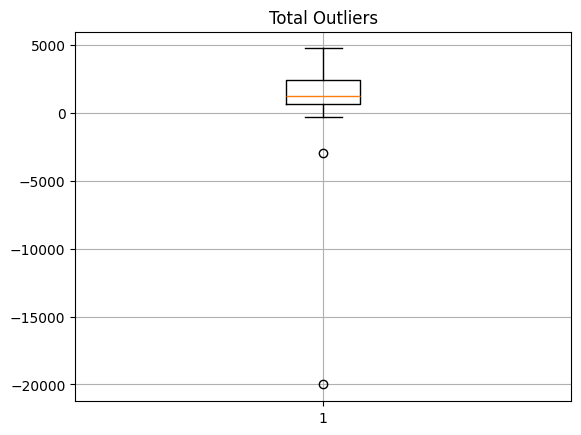

In [2105]:
plt.boxplot(df['Total'])
plt.title('Total Outliers')
plt.grid()
plt.show()

In [2106]:
Q1=df['Quantity'].quantile(0.25)
Q3=df['Quantity'].quantile(0.75)
print(Q1,Q3)

IQR=Q3-Q1
print(IQR)
L_limit=Q1-1.5*IQR
U_limit=Q3+1.5*IQR
print(L_limit)
print(U_limit)
outliers=df[(df['Quantity']<L_limit) | (df['Quantity']>U_limit)]
outliers


2.0 4.75
2.75
-2.125
8.875


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [2107]:
Q1=df['Total'].quantile(0.25)
Q3=df['Total'].quantile(0.75)
print(Q1,Q3)

IQR=Q3-Q1
print(IQR)
L_limit=Q1-1.5*IQR
U_limit=Q3+1.5*IQR
print(L_limit)
print(U_limit)
outliers=df[(df['Total']<L_limit) | (df['Total']>U_limit)]
outliers

645.263 2377.43
1732.167
-1952.9875000000002
4975.6805


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2025-02-12,Blender,electronic,2,10000,Cash on Delivery,Processing,-20000.00
34,134,Customer_134,ORD-16585,2025-10-04,T-shirt,clothing,5,591,PayPal,Shipped,-2957.65


In [2108]:
df['Total'].clip(L_limit,U_limit,inplace=True)

C:\Users\SANTHOSH\AppData\Local\Temp\ipykernel_16204\2137516093.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total'].clip(L_limit,U_limit,inplace=True)


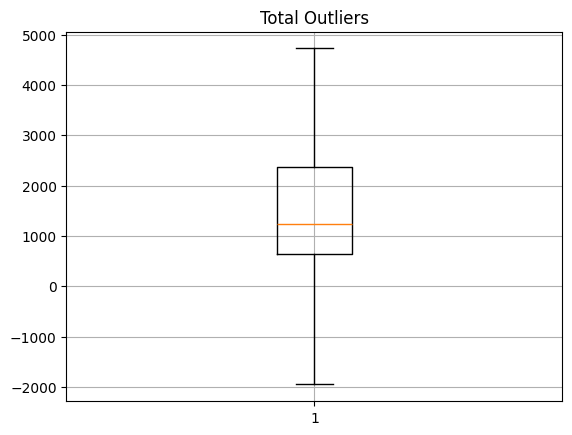

In [2109]:
plt.boxplot(df['Total'])
plt.title('Total Outliers')
plt.grid()
plt.show()

In [2110]:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
print(Q1,Q3)

IQR=Q3-Q1
print(IQR)
L_limit=Q1-1.5*IQR
U_limit=Q3+1.5*IQR
print(L_limit)
print(U_limit)
outliers=df[(df['Price']<L_limit) | (df['Price']>U_limit)]
outliers


292.5 702.75
410.25
-322.875
1318.125


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2025-02-12,Blender,electronic,2,10000,Cash on Delivery,Processing,-1952.9875


In [2111]:
df['Price'].clip(L_limit,U_limit,inplace=True)

C:\Users\SANTHOSH\AppData\Local\Temp\ipykernel_16204\465755298.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].clip(L_limit,U_limit,inplace=True)
C:\Users\SANTHOSH\AppData\Local\Temp\ipykernel_16204\465755298.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1318.125' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df['Price'].clip(L_limit,U_limit,inplace=True)


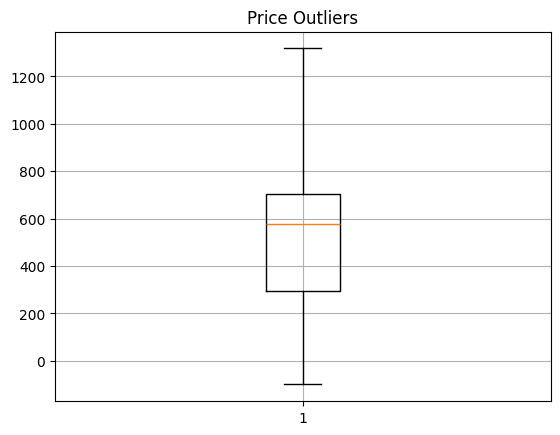

In [2112]:
plt.boxplot(df['Price'])
plt.title('Price Outliers')
plt.grid()
plt.show()

# Bi-Variate Analysis

## Numeric VS Numeric

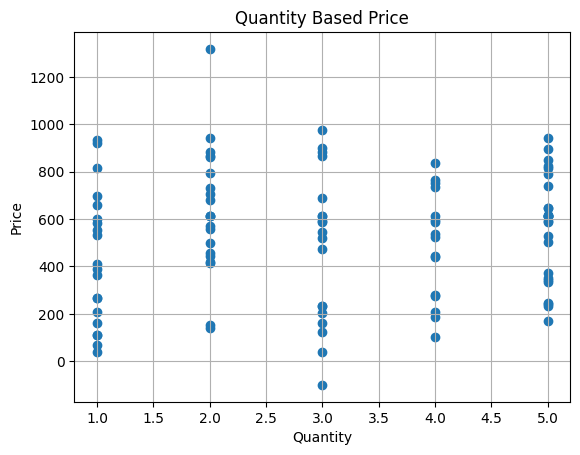

In [2113]:
plt.scatter(df['Quantity'],df['Price'])
plt.title('Quantity Based Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.grid()

## Numeric VS Category

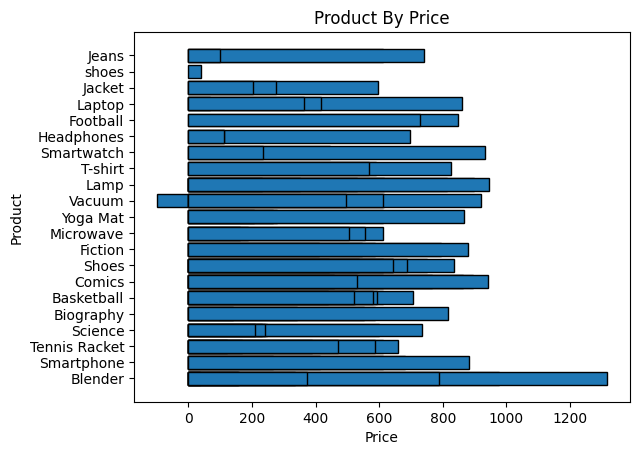

In [2114]:
plt.barh(df['Product'],df['Price'],edgecolor='black')
plt.title('Product By Price')
plt.xlabel('Price')
plt.ylabel('Product')
plt.show()


## Category VS Category

<Axes: xlabel=' Category'>

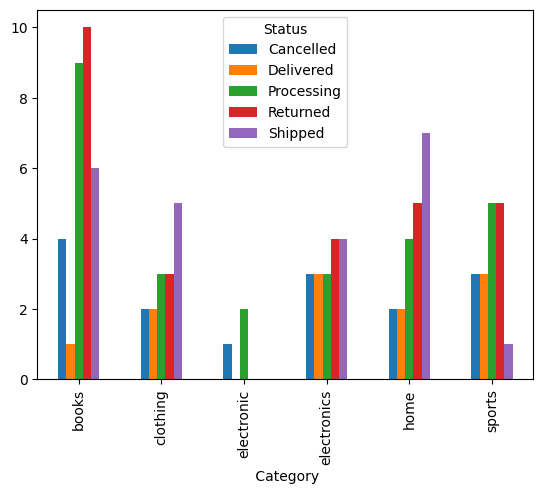

In [2115]:
df.groupby([' Category', 'Status']).size().unstack().plot(kind='bar',)

# Multi-Variate Analysis

Text(0.5, 1.0, 'Average price by category and payment_method')

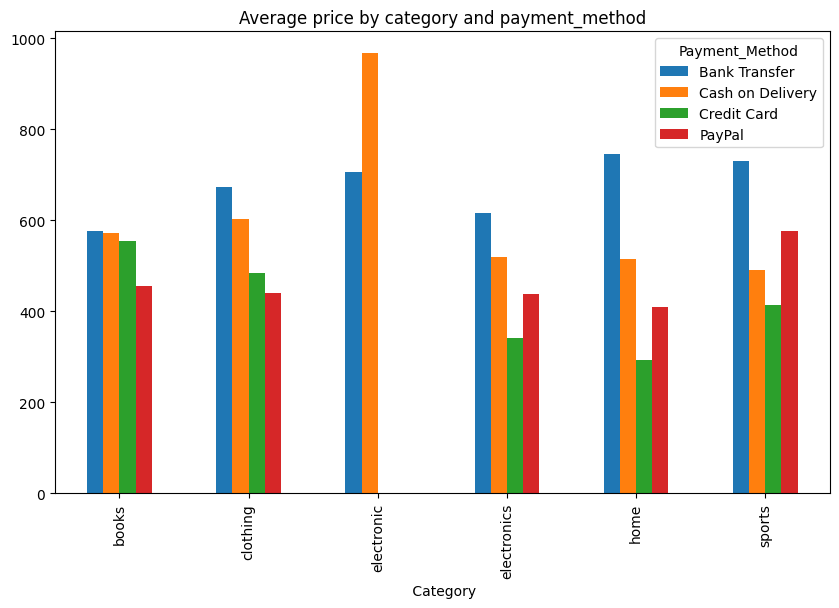

In [2116]:
grouped_mean = df.groupby([" Category", "Payment_Method"])["Price"].mean().unstack()
grouped_mean.plot(kind="bar", figsize=(10, 6))
plt.title("Average price by category and payment_method")

# Analyze Correlations

In [2117]:
correlation=df[['ID', 'Quantity', 'Price', 'Total']].corr()
correlation.reset_index(drop=True,inplace=True)

In [2118]:
correlation

,ID,Quantity,Price,Total
0,1.000000,-0.095417,-0.054778,0.008112
1,-0.095417,1.000000,0.075009,0.631034
2,-0.054778,0.075009,1.000000,0.512980
3,0.008112,0.631034,0.512980,1.000000


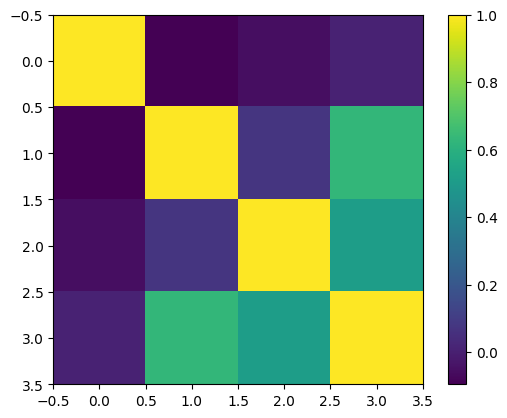

In [2119]:
plt.imshow(correlation)
plt.colorbar()

# Check data consistency

In [2120]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,home,3,38.0,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,electronics,2,611.0,PayPal,Processing,1222.00
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,sports,1,389.0,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,books,5,233.0,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,books,1,552.0,Cash on Delivery,Processing,552.51


In [2121]:
df.nunique()

ID                100
 Customer_Name    100
Order_ID          100
Order_Date         84
Product            21
 Category           6
Quantity            5
Price              89
Payment_Method      4
Status              5
Total              96
dtype: int64

In [2122]:
df.isna().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [2123]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int32
Price             float64
Payment_Method     object
Status             object
Total             float64
dtype: object

In [2124]:
df.duplicated().sum()

0

In [2125]:
df.describe()

,ID,Quantity,Price,Total
count,102.000000,102.000000,102.000000,102.000000
mean,149.676471,3.068627,526.383578,1531.228480
std,28.843779,1.477621,268.187684,1255.712588
min,100.000000,1.000000,-100.000000,-1952.987500
25%,125.250000,2.000000,292.500000,645.263000
50%,149.500000,3.000000,575.500000,1230.550000
75%,174.750000,4.750000,702.750000,2377.430000
max,199.000000,5.000000,1318.125000,4722.700000


# Feature understanding


In [2126]:
feature_identification=df[['ID', 'Quantity', 'Price', 'Total']].corr()
feature_identification.reset_index(drop=True,inplace=True)
feature_identification

,ID,Quantity,Price,Total
0,1.000000,-0.095417,-0.054778,0.008112
1,-0.095417,1.000000,0.075009,0.631034
2,-0.054778,0.075009,1.000000,0.512980
3,0.008112,0.631034,0.512980,1.000000


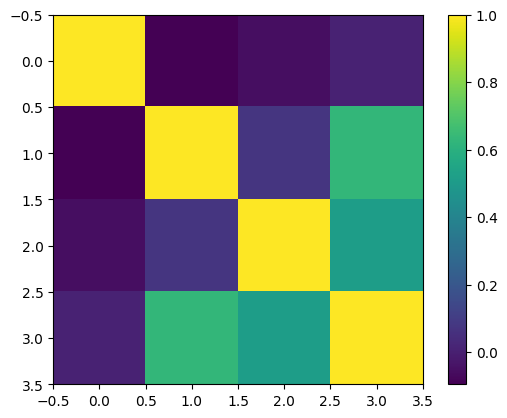

In [2127]:
plt.imshow(feature_identification)
plt.colorbar()

# Feature engineering (if needed)

In [2128]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,home,3,38.0,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,electronics,2,611.0,PayPal,Processing,1222.00
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,sports,1,389.0,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,books,5,233.0,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,books,1,552.0,Cash on Delivery,Processing,552.51
